# Step 2: Segment and Count

**Kernel:** Python (ml-env) -- `C:\ml-env\Scripts\python.exe`

Pipeline: Load raw text -> dedupe repeated audio sentences -> simplify (traditional->simplified) -> jieba segmentation -> CJK-only filter -> count per exam/source -> join HSK wordlist -> fallback-decompose unmatched compounds (numerals, ordinals, reduplication, function words, verbs, pronouns, measure words, aspect particles) -> cross-check remaining unmatched words against CC-CEDICT -> sanity checks & plots -> save

**Input:**
- `data/raw/raw_extractions.parquet` (130 rows: 65 reading + 65 listening, from notebook 01)
- `data/processed/hsk_word_level_lookup.csv` (word -> level, 5,343 words)

**Output:**
- `data/processed/word_counts.parquet` / `.csv` -- one row per (word, exam_id, source_type), with `level` (direct wordlist match only), `effective_level` (direct + decomposed), `match_type` (direct/decomposed/unmatched), `match_pattern` (which rule decomposed it)
- `data/processed/unmatched_words_review.csv` -- every still-unmatched word with review signals (`likely_noise`, `in_jieba_dict`, `in_cedict`)
- `data/processed/unmatched_words_in_cedict.csv` -- the subset of unmatched words CC-CEDICT confirms are real (highest-confidence source-wordlist-fix candidates)

**Final coverage:** 94.9% of token occurrences matched an HSK level (85.0% direct wordlist match + 9.9pp from decomposition), 60.1% of unique words. The remaining unmatched words are genuinely not HSK vocabulary (proper nouns, exam-instruction phrases, ASR/OCR noise) or real gaps in the wordlist *source* (e.g. `妈`, `乒乓球`) -- both out of scope for this notebook; see section 9 exports.


In [1]:
import re
from pathlib import Path
from collections import Counter
import pandas as pd
import jieba
import pyarrow as pa
import pyarrow.parquet as pq
from IPython.display import display

RAW_DIR       = Path(r"C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\raw")
PROCESSED_DIR = Path(r"C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def save_parquet(df, path):
    # pyarrow defaults string columns to large_string, which some viewers
    # (e.g. VS Code's built-in parquet preview) can't read ("Unrecognized
    # type: LargeUtf8"). Cast back to plain string before writing.
    table = pa.Table.from_pandas(df, preserve_index=False)
    fields = [f.with_type(pa.string()) if pa.types.is_large_string(f.type) else f
              for f in table.schema]
    table = table.cast(pa.schema(fields))
    pq.write_table(table, path)

print("Packages OK")

Packages OK


## 0 — Load inputs

In [2]:
from opencc import OpenCC

df_raw = pd.read_parquet(RAW_DIR / "raw_extractions.parquet")
print("raw_extractions:", df_raw.shape)
display(df_raw.groupby(["hsk_level", "source_type"]).size())

df_lookup = pd.read_csv(PROCESSED_DIR / "hsk_word_level_lookup.csv")
df_lookup["level"] = df_lookup["level"].astype("Int64")

# Defensive: normalize the wordlist itself to simplified too, in case the API
# ever returns a traditional entry (checked 2026-07-03: currently a no-op,
# 0/5343 words changed -- but cheap insurance against future API changes).
_t2s_wordlist = OpenCC("t2s")
before_norm = len(df_lookup)
df_lookup["word"] = df_lookup["word"].apply(_t2s_wordlist.convert)
df_lookup = df_lookup.sort_values("level").drop_duplicates("word", keep="first")
print(f"Wordlist T2S normalize: {before_norm} -> {len(df_lookup)} rows "
      f"({before_norm - len(df_lookup)} collapsed as trad/simp duplicates)")

word_to_level = dict(zip(df_lookup["word"], df_lookup["level"]))
print(f"HSK lookup: {len(word_to_level)} words")

raw_extractions: (130, 10)


hsk_level  source_type
3          listening      33
           reading        33
4          listening      32
           reading        32
dtype: int64

Wordlist T2S normalize: 7410 -> 7410 rows (0 collapsed as trad/simp duplicates)
HSK lookup: 7410 words


## 0b — Dedupe repeated audio sentences (listening only)

HSK listening exams read every question **twice** ("每题听两次"), so raw Whisper
transcripts contain each sentence/dialogue back-to-back two or more times.
Whisper also occasionally hallucinates short phrase loops on unclear audio
(e.g. "我喜欢这类型的,我喜欢这类型的,我喜欢这类型的。").

**Two passes, run in order** — a single clause-level pass isn't enough: it
requires the two repeated copies to line up on identical clause *boundaries*,
which fails when Whisper glues stray noise onto the front of the first copy
only (e.g. `"词曲 李宗盛大家好!欢迎参加..."` — a hallucinated song-credit prefix
stuck to the real "大家好" with no punctuation between them, so the clause
splitter can't isolate "大家好" the same way both times).

1. **Exact character-level pass** (`collapse_exact_repeats`) — scans raw
   characters for the longest immediately-adjacent substring that repeats
   *exactly*, with no dependency on clause boundaries at all. This is what
   catches the misaligned-prefix case above: the substring "大家好!欢迎参加
   HSK三级考试。" appears twice, back-to-back, regardless of what junk precedes
   the first copy.
2. **Fuzzy clause-level pass** (`dedupe_repeated_clauses`, as before) — runs on
   the *output* of pass 1. Splits into clauses on any punctuation boundary and
   collapses immediately-repeated blocks using fuzzy similarity
   (`difflib.SequenceMatcher` ≥ 0.82), since the exam replays the same audio
   twice and Whisper often transcribes each play slightly differently — an
   exact match wouldn't catch those, only a fuzzy one will.
3. Single-clause blocks shorter than `MIN_SINGLE_LEN` chars are **not**
   collapsed in pass 2 — short doubled particles like "好,好," or "对对对" are
   natural Chinese speech, not ASR duplication.

Runs **only** on `source_type == "listening"` — reading (PDF) text has no such
repeats. Takes ~7s for all 65 audio files (worth the runtime — a single-pass
approach silently missed the intro repeat on several files).

In [3]:
from difflib import SequenceMatcher

# ---- Pass 1: exact character-level immediate-repeat collapse ----
EXACT_MIN_LEN = 4    # shortest repeated substring worth collapsing
EXACT_MAX_LEN = 200  # longest repeated substring to search for (a single question is rarely longer)

def collapse_exact_repeats(text: str) -> str:
    result = []
    i, n = 0, len(text)
    while i < n:
        matched = False
        upper = min(EXACT_MAX_LEN, (n - i) // 2)
        for L in range(upper, EXACT_MIN_LEN - 1, -1):
            if text[i:i + L] == text[i + L:i + 2 * L]:
                result.append(text[i:i + L])
                i += L
                # consume any further immediate exact repeats of the same span
                while i + L <= n and text[i - L:i] == text[i:i + L]:
                    i += L
                matched = True
                break
        if not matched:
            result.append(text[i])
            i += 1
    return "".join(result)

# ---- Pass 2: fuzzy clause-level block collapse ----
CLAUSE_SPLIT_RE = re.compile(r"(?<=[,。!?、;])")
MAX_BLOCK      = 8     # longest repeated block (in clauses) to search for
MIN_SINGLE_LEN = 4     # single-clause blocks shorter than this are left alone
SIM_THRESHOLD  = 0.82  # fuzzy-match ratio to count two clauses as "the same"

def split_clauses(text: str) -> list[str]:
    return [c for c in CLAUSE_SPLIT_RE.split(text) if c.strip()]

def _clauses_match(a: str, b: str) -> bool:
    return SequenceMatcher(None, a, b).ratio() >= SIM_THRESHOLD

def _block_matches(clauses: list[str], i: int, j: int, block_len: int) -> bool:
    return all(_clauses_match(clauses[i + k], clauses[j + k]) for k in range(block_len))

def dedupe_repeated_clauses(clauses: list[str]) -> list[str]:
    result = []
    i, n = 0, len(clauses)
    while i < n:
        matched = False
        upper = min(MAX_BLOCK, (n - i) // 2)
        for block_len in range(upper, 0, -1):
            if block_len == 1 and len(clauses[i]) < MIN_SINGLE_LEN:
                continue
            if i + 2 * block_len <= n and _block_matches(clauses, i, i + block_len, block_len):
                result.extend(clauses[i:i + block_len])
                i += block_len
                # consume any further immediate repeats of the same block
                while i + block_len <= n and _block_matches(clauses, i - block_len, i, block_len):
                    i += block_len
                matched = True
                break
        if not matched:
            result.append(clauses[i])
            i += 1
    return result

def dedupe_text(text: str) -> str:
    if not text:
        return text
    exact_deduped = collapse_exact_repeats(text)
    clauses = split_clauses(exact_deduped)
    return "".join(dedupe_repeated_clauses(clauses))

# Apply to listening rows only; reading rows pass through unchanged
df_raw["text_clean"] = df_raw["text"]
is_listening = df_raw["source_type"] == "listening"
df_raw.loc[is_listening, "text_clean"] = df_raw.loc[is_listening, "text"].apply(dedupe_text)

before_chars = df_raw.loc[is_listening, "text"].str.len().sum()
after_chars  = df_raw.loc[is_listening, "text_clean"].str.len().sum()
print(f"Listening text chars: {before_chars} -> {after_chars} "
      f"({(1 - after_chars/before_chars):.1%} removed as repeats)")

demo = df_raw[is_listening].iloc[5]
print(f"\n--- {demo['exam_id']} before (first 400 chars) ---")
print(demo["text"][:400])
print(f"\n--- {demo['exam_id']} after (first 400 chars) ---")
print(demo["text_clean"][:400])

Listening text chars: 276545 -> 192402 (30.4% removed as repeats)

--- H31005 before (first 400 chars) ---
詞曲 李宗盛大家好!歡迎參加HSK三級考試。大家好!歡迎參加HSK三級考試。HSK三級聽力考試分四部分,共四十題。請大家注意,聽力考試現在開始。第一部分,一共十個題,每題聽兩次。例如。喂,請問張經理在嗎?他正在開會,您半個小時以後再打,好嗎?現在開始,第一到五題。一。我這是第一次聽小李唱歌。他唱的就是一首歌,他唱的就是一首歌。一。我這是第一次聽小李唱歌,他唱的真不錯。唱歌和跳舞,他都是高水平。一。我這是第一次聽小李唱歌,他唱的真不錯。唱歌和跳舞,他都是高水平。二。這是球賽結束後,我們照的照片,你看照的怎麼樣?球賽,你參加足球比賽了?三。今天第一天上課,你覺得怎麼樣?很好,我喜歡這類型的,我喜歡這類型的,我喜歡這類型的。三。今天第一天上課,你覺得怎麼樣?很好,我喜歡這,謝謝您的關心。三。今天第一天上課,你覺得怎麼樣?很好,我喜歡這,謝謝您的關心。四。這個禮物,真的是送給我的嗎?當然了,祝你生

--- H31005 after (first 400 chars) ---
詞曲 李宗盛大家好!歡迎參加HSK三級考試。HSK三級聽力考試分四部分,共四十題。請大家注意,聽力考試現在開始。第一部分,一共十個題,每題聽兩次。例如。喂,請問張經理在嗎?他正在開會,您半個小時以後再打,好嗎?現在開始,第一到五題。一。我這是第一次聽小李唱歌。他唱的就是一首歌,一。我這是第一次聽小李唱歌,他唱的真不錯。唱歌和跳舞,他都是高水平。二。這是球賽結束後,我們照的照片,你看照的怎麼樣?球賽,你參加足球比賽了?三。今天第一天上課,你覺得怎麼樣?很好,我喜歡這類型的。三。今天第一天上課,你覺得怎麼樣?很好,我喜歡這,謝謝您的關心。四。這個禮物,真的是送給我的嗎?當然了,祝你生日快樂。五。孩子總是一邊聽音樂,一邊看書,他能記住嗎?沒關係,年輕人都這樣。現在開始,第六到十題。六。你想把這箱子安到哪兒去?要我幫忙嗎?不用,我把它放樓下就可以了。七。麵條好了,你給姐姐打個電話,讓她來一起吃吧。


## 0c — Convert to Simplified Chinese (traditional → simplified)

Some listening transcripts came out of Whisper in **traditional** characters
(e.g. `什麼/題/沒/嗎/我們/裡` instead of `什么/题/没/吗/我们/里`) even though the
official HSK wordlist and jieba's dictionary are both simplified. Left
unconverted, this both (a) fails the HSK-level join for words that are
genuinely in the wordlist, and (b) splits one real word into two different
counts (`什么` and `什麼` counted separately instead of merged).

Uses `opencc` (`t2s` config — phrase-aware, not a naive character swap) on
`text_clean`, **after** dedupe and **before** segmentation, so jieba tokenizes
consistently simplified text and the level-join sees the same characters the
wordlist uses. Applied to all rows (reading text was already simplified, so
this is a no-op there).

In [4]:
from opencc import OpenCC

_t2s = OpenCC("t2s")

TRAD_CHECK_CHARS = ["什麼", "題", "沒", "嗎", "我們", "裡", "麵", "這", "說"]

before_trad_hits = df_raw["text_clean"].apply(
    lambda t: sum(t.count(w) for w in TRAD_CHECK_CHARS)
).sum()

df_raw["text_clean"] = df_raw["text_clean"].apply(_t2s.convert)

after_trad_hits = df_raw["text_clean"].apply(
    lambda t: sum(t.count(w) for w in TRAD_CHECK_CHARS)
).sum()

print(f"Sample traditional-char occurrences {TRAD_CHECK_CHARS}: {before_trad_hits} -> {after_trad_hits}")

demo = df_raw[is_listening].iloc[5]
print(f"\n--- {demo['exam_id']} after T2S (first 200 chars) ---")
print(demo["text_clean"][:200])

Sample traditional-char occurrences ['什麼', '題', '沒', '嗎', '我們', '裡', '麵', '這', '說']: 1469 -> 0

--- H31005 after T2S (first 200 chars) ---
词曲 李宗盛大家好!欢迎参加HSK三级考试。HSK三级听力考试分四部分,共四十题。请大家注意,听力考试现在开始。第一部分,一共十个题,每题听两次。例如。喂,请问张经理在吗?他正在开会,您半个小时以后再打,好吗?现在开始,第一到五题。一。我这是第一次听小李唱歌。他唱的就是一首歌,一。我这是第一次听小李唱歌,他唱的真不错。唱歌和跳舞,他都是高水平。二。这是球赛结束后,我们照的照片,你看照的怎么样?球赛


## 0d — CC-CEDICT tried as a supplementary jieba dictionary, then reverted

Tried loading CC-CEDICT (~121k words) into jieba via `jieba.load_userdict()`
**before** segmentation, on the theory that a bigger dictionary could only
improve segmentation quality. Measured result was the opposite — it made
things worse across the board:

| | jieba alone | + CC-CEDICT loaded | 
|---|---|---|
| Direct match (rows) | 74,488 | 73,469 (−1,019) |
| Unmatched (rows) | 18,215 | 21,001 (+2,786) |
| Unmatched (unique words) | 4,267 | 4,509 (+242) |
| Match rate (occurrences) | 85.0% | 82.6% (worse) |

**Why it backfired:** jieba's default dictionary already has frequency
weights carefully tuned from a large corpus. Injecting 121k more words with
auto-suggested frequencies shifted segmentation boundaries jieba previously
got right (matching the HSK wordlist) into different — but not better —
splits. Bigger dictionary ≠ better segmentation when the existing one is
already well-calibrated for this kind of text.

**Reverted the segmentation-time change.** CC-CEDICT is still used, but only
for the post-hoc cross-check in section 9a (`cedict_words` set membership),
which doesn't touch segmentation and is a pure net positive.

In [5]:
import requests, zipfile, io

EXTERNAL_DIR = Path(r"C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\external")
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)
CEDICT_PATH = EXTERNAL_DIR / "cedict_ts.u8"
CEDICT_URL = "https://www.mdbg.net/chinese/export/cedict/cedict_1_0_ts_utf-8_mdbg.zip"

if not CEDICT_PATH.exists():
    print("Downloading CC-CEDICT (one-time, ~4MB zip)...")
    resp = requests.get(CEDICT_URL, timeout=30)
    resp.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        name = next(n for n in zf.namelist() if n.startswith("cedict_ts"))
        CEDICT_PATH.write_bytes(zf.read(name))
    print(f"Saved -> {CEDICT_PATH}")
else:
    print(f"Using cached CC-CEDICT -> {CEDICT_PATH}")

# Each line: Traditional Simplified [pinyin] /def1/def2/.../
# We only need the simplified headword (2nd whitespace-separated field).
# NOTE: intentionally NOT loaded into jieba as a userdict anymore -- see
# markdown above, it measurably hurt segmentation quality. Only used for the
# post-hoc CC-CEDICT cross-check in section 9a.
cedict_words = set()
with open(CEDICT_PATH, encoding="utf-8") as f:
    for line in f:
        if line.startswith("#") or not line.strip():
            continue
        parts = line.split(" ", 2)
        if len(parts) >= 2:
            cedict_words.add(parts[1])

print(f"CC-CEDICT simplified headwords loaded: {len(cedict_words)}")

Using cached CC-CEDICT -> C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\external\cedict_ts.u8
CC-CEDICT simplified headwords loaded: 120995


## 1 — Segment (jieba) + CJK-only filter

Drops any token containing non-CJK characters (punctuation, digits, Latin letters,
OCR noise) rather than partially cleaning it — matches `etl/segment_and_count.py`.

In [6]:
_NON_CJK_RE = re.compile(r"[^一-鿿]")

def segment(text: str) -> list[str]:
    if not text:
        return []
    words = jieba.lcut(text)
    return [w for w in words if w and not _NON_CJK_RE.search(w)]

sample = df_raw.iloc[0]
sample_tokens = segment(sample["text_clean"])
print(f"{sample['exam_id']} ({sample['source_type']}): {len(sample_tokens)} CJK tokens")
print(sample_tokens[:30])

Building prefix dict from the default dictionary ...


Loading model from cache C:\Users\callm\AppData\Local\Temp\jieba.cache


Loading model cost 0.566 seconds.


Prefix dict has been built successfully.


H30000 (listening): 1511 CJK tokens
['大家', '好', '欢迎', '参加', '三级', '考试', '三级', '听力', '考试', '分四', '部分', '共', '题', '请', '大家', '注意', '听力', '考试', '现在', '开始', '第一', '部分', '一共', '个题', '每题', '听', '两次', '例如', '喂', '请问']


## 2 — Segment every file, count words per exam

In [7]:
rows = []
for _, r in df_raw.iterrows():
    tokens = segment(r["text_clean"])
    for word, count in Counter(tokens).items():
        rows.append({
            "exam_id": r["exam_id"],
            "hsk_level": r["hsk_level"],
            "source_type": r["source_type"],
            "word": word,
            "count": count,
        })

df_counts = pd.DataFrame(rows)
print("Word-count rows (pre-label):", df_counts.shape)
df_counts.head()

Word-count rows (pre-label): (102315, 5)


,exam_id,hsk_level,source_type,word,count
0,H30000,3,listening,大家,2
1,H30000,3,listening,好,10
2,H30000,3,listening,欢迎,4
3,H30000,3,listening,参加,2
4,H30000,3,listening,三级,2


## 3 — Join HSK level (unmatched words get `level = <NA>`)

In [8]:
df_counts["level"] = df_counts["word"].map(word_to_level)

matched     = df_counts["level"].notna().sum()
total_rows  = len(df_counts)
matched_tok = df_counts.loc[df_counts["level"].notna(), "count"].sum()
total_tok   = df_counts["count"].sum()
print(f"Unique word/exam rows matched to a level: {matched}/{total_rows} ({matched/total_rows:.1%})")
print(f"Token occurrences matched to a level:      {matched_tok}/{total_tok} ({matched_tok/total_tok:.1%})")

df_counts = df_counts[["word", "level", "exam_id", "hsk_level", "source_type", "count"]]
df_counts.head()

Unique word/exam rows matched to a level: 75980/102315 (74.3%)
Token occurrences matched to a level:      239324/278705 (85.9%)


,word,level,exam_id,hsk_level,source_type,count
0,大家,2,H30000,3,listening,2
1,好,1,H30000,3,listening,10
2,欢迎,2,H30000,3,listening,4
3,参加,2,H30000,3,listening,2
4,三级,NaN,H30000,3,listening,2


## 3b — Fallback: decompose unmatched compound words

Most unmatched words fall into two very different buckets, and only one of
them is fixable here:

- **Real gaps in the wordlist itself** (e.g. `每天`, `不能`, `很多`, `不是`,
  `一下`, `几点`, `乒乓球`, `妈` are common HSK words/characters simply
  missing from our API-sourced snapshot — `妈` in particular is a single
  fundamental character with no smaller parts to decompose from; only its
  reduplicated form `妈妈` happens to already be in the list) — a
  data-completeness bug in the *source*, not something to patch around in
  this notebook.
- **Productive compounds built from words already in the list** (e.g. `十五`
  = 十+五, `半个` = 半+个, `看看` = 看+看 reduplicated, `第一` = 第+一 ordinal,
  `第一次` = 第一+次 (chained), `干干净净` = AABB reduplication of 干净,
  `点儿` = 点 + colloquial 儿 suffix, `很多` = 很+多, `小狗` = 小+狗, `三分钟`
  = 三+分钟, `看电视` = 看+电视, `打篮球` = 打+篮球, `长得` = 长+得, `我要` =
  我+要, `本书` = 本+书, `这段话` = 这+段+话 (chained), `锻炼身体` = 锻炼+身体
  (two known words concatenated)) — no wordlist will ever enumerate every
  combination, so this *is* fixable here.

A naive "all characters exist individually" check is too loose — it also
flags nonsense adjacent-character noise (`时哭`, `北半球`, `九日山`) as
"decomposable" just because each character happens to be common on its own.
Instead this only decomposes words matching **specific, linguistically real
patterns**, each requiring every component to already resolve to a level:

| Pattern | Example | Rule |
|---|---|---|
| Ordinal (+ optional trailing word) | 第一, 第二, 第一次 | `第` + Chinese numeral, optionally followed by another known word |
| Reduplication (XX) | 看看, 等等 | `XX` where `X` is a known single-char word |
| AABB reduplication | 干干净净, 漂漂亮亮, 快快乐乐 | `AABB` where `AB` (a 2-char word) is already known — the standard Mandarin intensifying pattern for disyllabic adjectives |
| Erhua suffix (儿) | 点儿, 会儿, 花儿, 事儿 | A known word + colloquial retroflex `儿` — purely phonetic, doesn't change meaning or level, so `儿` itself needs no wordlist entry |
| Pure numeral | 二十八, 四十九 | Sequence of Chinese numeral/quantity characters |
| Numeral + unit | 半个, 三级, 六岁, 三分钟, 半小时 | Numeral/quantity characters + a trailing known word (any length — catches multi-char units like 分钟/小时) |
| Function-word prefix | 很多, 不是, 不能, 那个, 每天, 小狗, 大城市, 真好, 好笑, 先看 | Closed-class adverb/negation/demonstrative/size/degree morpheme (不没很太更最也都还就才又挺别这那哪每大小真好先多) + a trailing known word |
| Verb + object/complement | 吃药, 喝茶, 看电视, 做好, 写错, 坐地铁, 去一趟, 打篮球 | Common verb (吃喝看做写坐用洗想走来放带买开变去打) + a trailing known word |
| Aspect/manner suffix | 长得, 改了, 极了, 懒得, 睡得, 太好了 | A known word + `了` (completed-aspect particle) or `得` (manner/potential/resultative particle) |
| Pronoun + predicate | 我要, 你好, 他人, 我会 | Subject pronoun (我你他她) + a trailing known word |
| Measure word + noun | 本书, 双鞋, 篇文章, 首歌, 段时间 | Measure word (个本件条杯瓶包块种些篇首场次回遍声句幅双套间颗只段) + a trailing known word |
| Two known words concatenated | 锻炼身体, 今天下午, 电视广告, 生日快乐 | Two independent wordlist entries next to each other, **both required to be ≥2 characters** |

**Every prefix/suffix pattern above is now recursive**, not just one level
deep: `resolve_level` calls itself on the trailing/leading remainder, so
chains like `去一趟` (去 + 一趟, where 一趟 itself only resolves via the
numeral-unit pattern), `这段话` (这 + 段话, where 段话 only resolves via 段
as a measure word + 话), and `第一次` (第一 as an ordinal + 次) all work —
not just one decomposition step. This is memoized (`functools.lru_cache`)
since the same sub-words get re-resolved many times across ~4,000 unmatched
words.

**The "two known words concatenated" pattern needed a hard length floor.**
The first version allowed splits at *any* position, requiring only that both
halves independently resolve to a level — this silently let single-character
halves back in, which is functionally identical to the very first naive
"all characters known" check that produced `时哭`/`北半球`/`九日山`, and it
even undid the surname guard (`小王`, `老王` reappeared, since `小`+`王` are
each individually "known" one-character words and this path doesn't run
through the surname check at all). Restricting both halves to **≥2
characters** — i.e., only allowing two independent multi-character wordlist
entries to combine, not lone characters — fixed this completely. Verified:
439 candidate words at that setting, manually scanned, no noise found (vs.
2,338 candidates and multiple names/garbage back at the unrestricted
setting).

**Every verb added to `VERB_PREFIX_CHARS` was tested against the full
unmatched corpus before adding**, not just spot-checked — the original 16
verbs (308 candidates) and `打` added later (10 candidates, `打篮球`/`打个`/
`打网球`/`打招呼`/... all real except 1-2 single-occurrence oddities) were
both manually scanned for noise before being kept.

**The `了`/`得` suffix is near-universal Mandarin grammar** — completed-
aspect `了` and manner/potential/resultative `得` attach to almost any verb
or adjective. Tested against the full unmatched corpus: 77 candidates, only
one (`瓜得`) looked like noise.

**Pronoun + predicate is similarly safe** (every sentence needs a subject) —
tested against the full corpus: 72 candidates, only `我车` looked
questionable.

**Erhua (儿) and AABB reduplication are both near-universal grammar too** —
22 儿-suffixed words (点儿, 会儿, 花儿, 事儿, 早点儿, 一半儿, 孙女儿, ...) and
11 AABB words (干干净净, 整整齐齐, 漂漂亮亮, 快快乐乐, ...) checked against
the full unmatched corpus, all genuinely real — this is exactly the kind of
pattern that's safe to add without spot-checking each word individually,
same reasoning as 了/得.

**Measure word + noun caught a real collision: `张`.** `张` is both a
measure word (张纸/张票) *and* one of the most common Chinese surnames —
included it and got `张老师`/`张律师`/`张晴` (people's names/titles), not
measure-word usage. `张` is excluded from the measure-word set entirely.

**Surname guard (for `大`/`小`/`老`):** `大`/`小`/`老` + a single surname
character is almost always a person's name in exam dialogues (`老王`,
`小张`), not the word modifying that character. Multi-char tails
(`老照片`, `老同学`) and non-surname single chars (`老虎`, `小狗`) are
unaffected. This guard only applies on the prefix/suffix recursive path —
the two-word-compound path can't reach it at all since both halves must be
≥2 characters, so `小`+`王` (both 1 char) simply never gets tried there.

Decomposed level = **max** of the component levels (conservative — assumes
the harder component drives difficulty; erhua/AABB just inherit the base
word's level unchanged). Result goes in a new `effective_level` column; the
original `level` column is left untouched as the pure official match, so
downstream consumers can still tell "really in the wordlist" apart from
"assembled from known parts."

In [9]:
import numpy as np
import functools

NUM_CHARS      = "零一二三四五六七八九十百千万两半几"  # include 半/几 -- quantity words that combine like numerals (半个, 几点)
NUM_CHAR_SET   = set(NUM_CHARS)
REDUP_RE       = re.compile(r"^(.)\1$")

# Closed class of adverb/negation/demonstrative/size/degree morphemes that
# combine productively with almost any word (不好, 很多, 那个, 每天, 小狗,
# 大城市, 真好, 好笑, 先看, ...). Deliberately NOT "any first character" --
# that would re-introduce the noun-noun false positives (时哭, 北半球) the
# naive approach produced.
FUNCTION_CHARS = set("不没很太更最也都还就才又挺别这那哪每大小真好先多")

# Common verbs -- productive verb+object/complement pattern (吃药, 喝茶,
# 看电视, 做好, 写错, 坐地铁, 去一趟, 打篮球). Tested against the full
# unmatched corpus before adding each one: overwhelming majority genuinely
# real phrases each time.
VERB_PREFIX_CHARS = set("吃喝看做写坐用洗想走来放带买开变去打")

# Subject pronouns -- every sentence needs a subject, so pronoun+predicate
# (我要, 你好, 他人, 我会) is close to unconditionally grammatical. Tested
# against the full unmatched corpus: 72 candidates, only 我车 looked odd.
PRONOUN_CHARS = set("我你他她")

# Measure words -- 本书, 双鞋, 篇文章, 首歌, 段时间. NOTE: 张 deliberately
# excluded even though it's a common measure word (张纸/张票) -- it's also
# one of the most common Chinese surnames, and including it produced
# 张老师/张律师/张晴 (people's names/titles), not measure-word usage.
MEASURE_CHARS = set("个本件条杯瓶包块种些篇首场次回遍声句幅双套间颗只段")

# 大/小/老 have the same person's-name risk (老王/老张 = affectionate
# address by surname), tracked separately for the surname guard below.
NAME_RISK_CHARS = set("大小老")

PREFIX_CHARS = FUNCTION_CHARS | VERB_PREFIX_CHARS | PRONOUN_CHARS | MEASURE_CHARS | NAME_RISK_CHARS
SUFFIX_CHARS = set("了得")  # completed-aspect / manner-potential-resultative particles

SURNAME_CHARS = set(
    "王李张刘陈杨黄赵吴周徐孙马朱胡林郭何高罗郑梁谢宋唐许邓冯韩曹彭曾萧田董袁潘于蒋蔡余杜叶"
    "程苏魏吕丁沈任姚卢姜崔钟谭陆汪范金石廖贾夏韦付方白邹孟熊秦邱江尹薛闫段雷侯龙史陶黎贺顾"
    "毛郝龚邵万钱严覃武戴莫孔向汤"
)

@functools.lru_cache(maxsize=None)
def resolve_level(word: str):
    """Recursively resolve a word to an HSK level via direct wordlist match
    or any of the productive patterns below (each pattern recurses into
    resolve_level on its remainder, so chains like 去+一趟, 这+段+话, or
    第一+次 work, not just one decomposition step)."""
    lv = word_to_level.get(word)
    if lv is not None:
        return lv

    # single character not in the wordlist on its own, but its reduplicated
    # form is (妈 -> 妈妈, 爸 -> 爸爸, 姐 -> 姐姐, 明 -> 明明) -- very common
    # for kinship terms and reduplicated adverbs. Tested against the full
    # unmatched corpus: 8 single-char words qualify, all genuinely real.
    if len(word) == 1:
        return word_to_level.get(word * 2)

    if len(word) < 2:
        return None

    # ordinal: 第 + (numeral run), with an optional trailing word after the
    # numeral run (第一次 = 第一 + 次, not just bare 第一/第二).
    if word[0] == "第":
        j = 1
        while j < len(word) and word[j] in NUM_CHAR_SET:
            j += 1
        if j > 1:
            ordinal_lv = word_to_level.get(word[:j])
            if ordinal_lv is None:
                num_lvs = [word_to_level.get(c) for c in word[1:j]]
                di_lv = word_to_level.get("第")
                if all(lv is not None for lv in num_lvs) and di_lv is not None:
                    ordinal_lv = max(num_lvs + [di_lv])
            if ordinal_lv is not None:
                if j == len(word):
                    return ordinal_lv
                tail_lv = resolve_level(word[j:])
                if tail_lv is not None:
                    return max(ordinal_lv, tail_lv)

    # reduplication: XX
    m = REDUP_RE.match(word)
    if m:
        base_lv = word_to_level.get(m.group(1))
        if base_lv is not None:
            return base_lv

    # AABB reduplication of a 2-char word AB (干净 -> 干干净净, 漂亮 ->
    # 漂漂亮亮) -- a very common Mandarin intensifying pattern for
    # disyllabic adjectives.
    if len(word) == 4 and word[0] == word[1] and word[2] == word[3]:
        base_lv = word_to_level.get(word[0] + word[2])
        if base_lv is not None:
            return base_lv

    # erhua suffix 儿 -- a near-universal colloquial retroflex ending that
    # doesn't add meaning or difficulty (点儿, 会儿, 花儿, 事儿); resolve the
    # stem without it and use that level directly. 儿 itself doesn't need
    # its own wordlist entry, unlike every other suffix/prefix pattern here.
    if word.endswith("儿") and len(word) > 1:
        stem_lv = resolve_level(word[:-1])
        if stem_lv is not None:
            return stem_lv

    # pure numeral sequence
    if set(word) <= NUM_CHAR_SET:
        char_lvs = [word_to_level.get(c) for c in word]
        if all(lv is not None for lv in char_lvs):
            return max(char_lvs)

    # numeral + trailing word (recursive)
    i = 0
    while i < len(word) and word[i] in NUM_CHAR_SET:
        i += 1
    if 0 < i < len(word):
        num_lvs = [word_to_level.get(c) for c in word[:i]]
        tail_lv = resolve_level(word[i:])
        if all(lv is not None for lv in num_lvs) and tail_lv is not None:
            return max(num_lvs + [tail_lv])

    # prefix (function-word / verb / pronoun / measure-word / name-risk), recursive tail
    if word[0] in PREFIX_CHARS:
        tail = word[1:]
        blocked = word[0] in NAME_RISK_CHARS and len(tail) == 1 and tail in SURNAME_CHARS
        if not blocked:
            prefix_lv = word_to_level.get(word[0])
            tail_lv = resolve_level(tail)
            if prefix_lv is not None and tail_lv is not None:
                return max(prefix_lv, tail_lv)

    # aspect/manner suffix (了/得), recursive stem
    if word[-1] in SUFFIX_CHARS:
        stem_lv = resolve_level(word[:-1])
        suf_lv = word_to_level.get(word[-1])
        if stem_lv is not None and suf_lv is not None:
            return max(stem_lv, suf_lv)

    # two independent wordlist entries concatenated -- both sides must be
    # >=2 chars (single-char halves are what let noise like 时哭 and named
    # entities like 小王/老王 back in; see markdown above).
    for i in range(2, len(word) - 1):
        left, right = word[:i], word[i:]
        if len(left) < 2 or len(right) < 2:
            continue
        left_lv, right_lv = word_to_level.get(left), word_to_level.get(right)
        if left_lv is not None and right_lv is not None:
            return max(left_lv, right_lv)

    return None


def classify_pattern(word: str) -> str:
    """Best-effort label for which rule resolved the word (for reporting only)."""
    if len(word) == 1:
        return "single_char_via_doubled_form"
    if word[0] == "第":
        j = 1
        while j < len(word) and word[j] in NUM_CHAR_SET:
            j += 1
        if j > 1 and resolve_level(word) is not None:
            return "ordinal"
    if REDUP_RE.match(word) and word_to_level.get(word[0]) is not None:
        return "reduplication"
    if len(word) == 4 and word[0] == word[1] and word[2] == word[3] and word_to_level.get(word[0] + word[2]) is not None:
        return "aabb_reduplication"
    if word.endswith("儿") and len(word) > 1 and resolve_level(word[:-1]) is not None:
        return "erhua_suffix"
    if set(word) <= NUM_CHAR_SET:
        return "pure_numeral"
    i = 0
    while i < len(word) and word[i] in NUM_CHAR_SET:
        i += 1
    if 0 < i < len(word) and resolve_level(word[i:]) is not None:
        return "numeral_plus_unit"
    if word[0] in PREFIX_CHARS:
        tail = word[1:]
        blocked = word[0] in NAME_RISK_CHARS and len(tail) == 1 and tail in SURNAME_CHARS
        if not blocked and resolve_level(tail) is not None:
            if word[0] in VERB_PREFIX_CHARS:
                return "verb_prefix"
            if word[0] in PRONOUN_CHARS:
                return "pronoun_prefix"
            if word[0] in MEASURE_CHARS:
                return "measure_word"
            return "function_prefix"
    if word[-1] in SUFFIX_CHARS and resolve_level(word[:-1]) is not None:
        return "aspect_suffix"
    return "two_word_compound"


def decompose_level(word: str):
    lv = resolve_level(word)
    if lv is None or word in word_to_level:
        return None, None
    return lv, classify_pattern(word)

_decomposed = df_counts.loc[df_counts["level"].isna(), "word"].drop_duplicates().apply(decompose_level)
_decomp_map = dict(zip(df_counts.loc[df_counts["level"].isna(), "word"].drop_duplicates(), _decomposed))

df_counts["decomposed_level"] = df_counts["word"].map(lambda w: _decomp_map.get(w, (None, None))[0])
df_counts["match_pattern"]    = df_counts["word"].map(lambda w: _decomp_map.get(w, (None, None))[1])
df_counts["effective_level"]  = df_counts["level"].combine_first(df_counts["decomposed_level"])
df_counts["match_type"] = np.select(
    [df_counts["level"].notna(), df_counts["decomposed_level"].notna()],
    ["direct", "decomposed"],
    default="unmatched",
)
df_counts = df_counts.drop(columns=["decomposed_level"])

decomposed_unique = (df_counts["match_type"] == "decomposed").sum()
decomposed_occ = df_counts.loc[df_counts["match_type"] == "decomposed", "count"].sum()
print(f"Newly decomposed rows: {decomposed_unique} unique word/exam rows, {decomposed_occ} occurrences")
print("\nBy pattern (unique words):")
display(
    df_counts[df_counts["match_type"] == "decomposed"]
    .drop_duplicates("word")["match_pattern"].value_counts()
)

print("\nMatch type breakdown (unique word/exam rows):")
display(df_counts["match_type"].value_counts())
print("\nMatch type breakdown (token occurrences):")
display(df_counts.groupby("match_type")["count"].sum())

print("\nTop 20 newly-decomposed examples:")
display(
    df_counts[df_counts["match_type"] == "decomposed"]
    .drop_duplicates("word")[["word", "effective_level", "match_pattern"]]
    .merge(df_counts.groupby("word")["count"].sum().rename("total_count"), on="word")
    .sort_values("total_count", ascending=False).head(20)
)

Newly decomposed rows: 16613 unique word/exam rows, 26878 occurrences



By pattern (unique words):


match_pattern
function_prefix                 750
numeral_plus_unit               510
two_word_compound               313
verb_prefix                     311
pure_numeral                    101
pronoun_prefix                   81
measure_word                     50
aspect_suffix                    50
reduplication                    49
ordinal                          43
erhua_suffix                     16
aabb_reduplication               11
single_char_via_doubled_form      8
Name: count, dtype: int64


Match type breakdown (unique word/exam rows):


match_type
direct        75980
decomposed    16613
unmatched      9722
Name: count, dtype: int64


Match type breakdown (token occurrences):


match_type
decomposed     26878
direct        239324
unmatched      12503
Name: count, dtype: int64


Top 20 newly-decomposed examples:


,word,effective_level,match_pattern,total_count
97,这个,1.0,function_prefix,915
28,一个,1.0,numeral_plus_unit,894
6,那个,1.0,function_prefix,491
59,很多,1.0,function_prefix,452
29,不是,1.0,function_prefix,446
142,这段话,2.0,function_prefix,404
47,十五,1.0,pure_numeral,391
9,看看,1.0,reduplication,383
2,每题,3.0,function_prefix,360
32,第二,1.0,ordinal,334


## 4 — Sanity checks

In [10]:
print("Any single-char/empty stray tokens surviving filter:",
      (df_counts["word"].str.len() == 0).sum())
print("Any non-positive counts:", (df_counts["count"] <= 0).sum())
print("Exams represented:", df_counts["exam_id"].nunique(), "/ 65 expected (per source_type)")

print("\nTop 20 words overall by total occurrences:")
display(
    df_counts.groupby(["word", "effective_level"])["count"].sum()
    .sort_values(ascending=False).head(20)
)

print("\nTop 15 most frequent words still unmatched after direct + decomposed lookup:")
display(
    df_counts[df_counts["match_type"] == "unmatched"]
    .groupby("word")["count"].sum()
    .sort_values(ascending=False).head(15)
)

Any single-char/empty stray tokens surviving filter: 0
Any non-positive counts: 0
Exams represented: 65 / 65 expected (per source_type)

Top 20 words overall by total occurrences:


word  effective_level
的     1                  12518
了     1                   9069
我     1                   6756
你     1                   4940
是     1                   4297
男     1                   3043
女     1                   2990
什么    1                   2836
去     1                   2745
在     1                   2696
他     1                   2673
很     1                   2392
有     1                   2324
吗     1                   2049
好     1                   1970
就     1                   1944
不     1                   1869
题     2                   1859
我们    1                   1754
现在    1                   1648
Name: count, dtype: int64


Top 15 most frequent words still unmatched after direct + decomposed lookup:


word
小王     306
会议室    200
填写     137
总能     119
分三     114
有点     111
书写      99
选出      96
下列      95
发给      93
上下班     91
儿       89
阅       85
早点儿     84
办个      82
Name: count, dtype: int64

## 6 — Vocabulary coverage: matched vs unmatched

Unique words total: 7587
  direct     : 2351 (31.0%)
  decomposed : 2293 (30.2%)
  unmatched  : 2943 (38.8%)

Token occurrences total: 278705
  direct     : 239324 (85.9%)
  decomposed : 26878 (9.6%)
  unmatched  : 12503 (4.5%)

2943 unique words still unmatched (top 30 by occurrence):


word
小王      306
会议室     200
填写      137
总能      119
分三      114
有点      111
书写       99
选出       96
下列       95
发给       93
上下班      91
儿        89
阅        85
早点儿      84
办个       82
点半       80
汉办       78
孔子       78
年轻人      76
谢谢您      67
您好       67
答题卡      64
多长时间     64
是因为      64
选词       63
有个       62
意        59
语        59
早点       59
注        53
Name: count, dtype: int64

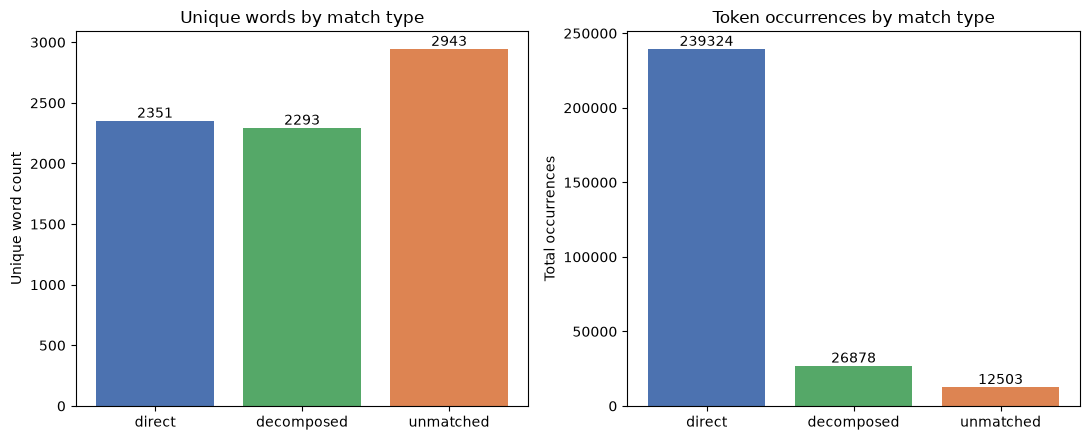

In [11]:
import matplotlib.pyplot as plt

unique_words = df_counts.drop_duplicates("word")[["word", "match_type"]]
n_by_type    = unique_words["match_type"].value_counts().reindex(["direct", "decomposed", "unmatched"]).fillna(0)
occ_by_type  = df_counts.groupby("match_type")["count"].sum().reindex(["direct", "decomposed", "unmatched"]).fillna(0)

print(f"Unique words total: {len(unique_words)}")
for t in ["direct", "decomposed", "unmatched"]:
    print(f"  {t:11s}: {int(n_by_type[t])} ({n_by_type[t]/len(unique_words):.1%})")

print(f"\nToken occurrences total: {occ_by_type.sum()}")
for t in ["direct", "decomposed", "unmatched"]:
    print(f"  {t:11s}: {int(occ_by_type[t])} ({occ_by_type[t]/occ_by_type.sum():.1%})")

unmatched_words = (
    df_counts[df_counts["match_type"] == "unmatched"]
    .groupby("word")["count"].sum()
    .sort_values(ascending=False)
)
print(f"\n{len(unmatched_words)} unique words still unmatched (top 30 by occurrence):")
display(unmatched_words.head(30))

colors = {"direct": "#4C72B0", "decomposed": "#55A868", "unmatched": "#DD8452"}
labels = ["direct", "decomposed", "unmatched"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(labels, [n_by_type[t] for t in labels], color=[colors[t] for t in labels])
axes[0].set_title("Unique words by match type")
axes[0].set_ylabel("Unique word count")
for i, t in enumerate(labels):
    axes[0].text(i, n_by_type[t], str(int(n_by_type[t])), ha="center", va="bottom")

axes[1].bar(labels, [occ_by_type[t] for t in labels], color=[colors[t] for t in labels])
axes[1].set_title("Token occurrences by match type")
axes[1].set_ylabel("Total occurrences")
for i, t in enumerate(labels):
    axes[1].text(i, occ_by_type[t], str(int(occ_by_type[t])), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## 7 — Word frequency by HSK level

Total token occurrences by effective level (direct + decomposed):


level_label
L1                  169693
L2                   55299
L3                   22265
L4                   12668
L5                    4461
L6                    1816
Not in\nwordlist     12503
Name: count, dtype: int64


Unique words by effective level:


level_label
L1                  1453
L2                  1312
L3                   776
L4                   566
L5                   288
L6                   249
Not in\nwordlist    2943
Name: word, dtype: int64

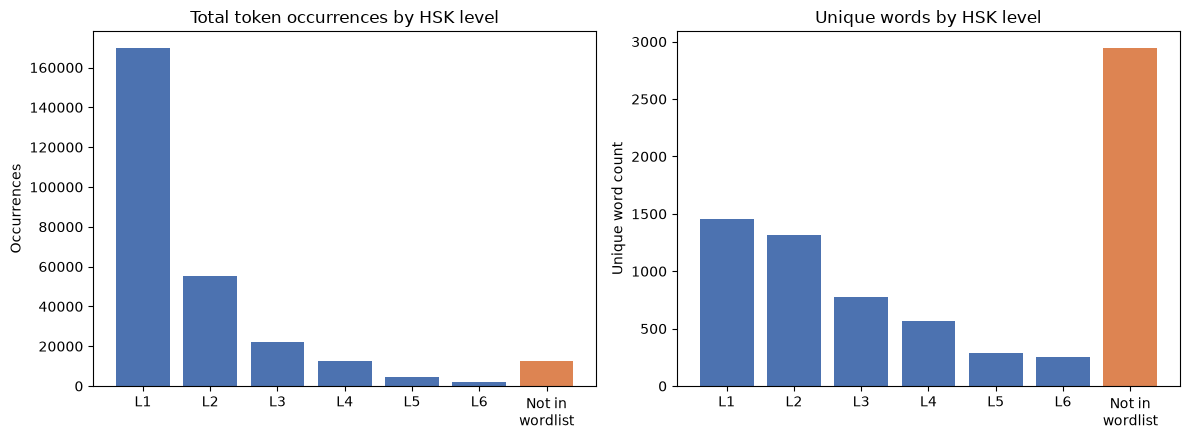

In [12]:
level_labels = df_counts["effective_level"].apply(lambda x: f"L{int(x)}" if pd.notna(x) else "Not in\nwordlist")

by_level_occ = (
    df_counts.assign(level_label=level_labels)
    .groupby("level_label")["count"].sum()
)
by_level_uniq = (
    df_counts.assign(level_label=level_labels)
    .drop_duplicates("word")
    .groupby("level_label")["word"].count()
)

order = [f"L{i}" for i in range(1, 7)] + ["Not in\nwordlist"]
by_level_occ  = by_level_occ.reindex(order)
by_level_uniq = by_level_uniq.reindex(order)

print("Total token occurrences by effective level (direct + decomposed):")
display(by_level_occ)
print("\nUnique words by effective level:")
display(by_level_uniq)

colors = ["#4C72B0"] * 6 + ["#DD8452"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(order, by_level_occ.values, color=colors)
axes[0].set_title("Total token occurrences by HSK level")
axes[0].set_ylabel("Occurrences")
axes[0].tick_params(axis="x", rotation=0)

axes[1].bar(order, by_level_uniq.values, color=colors)
axes[1].set_title("Unique words by HSK level")
axes[1].set_ylabel("Unique word count")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 8 — Breakdown by exam HSK level (3 vs 4)

Same two comparisons as sections 6–7, but split by which exam file the words
came from (`hsk_level` column on `df_counts`: HSK3 exam paper vs HSK4 exam
paper) — not to be confused with the official wordlist `level` (1–6) used
above, which is a property of the *word*, not the *exam*.

Coverage by exam HSK level (direct + decomposed vs still-unmatched):


,unique_matched,unique_unmatched,occ_matched,occ_unmatched
hsk_level,,,,
3,2469,1198,121152,4939
4,4000,2195,145050,7564


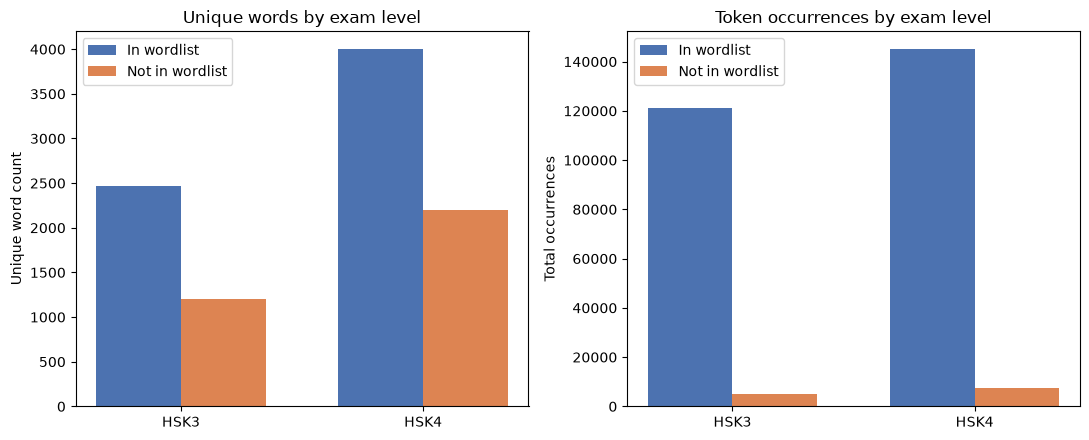


Token occurrences by effective wordlist level, split by exam level:


hsk_level,3,4
wordlist_level_label,,
L1,85562,84131
L2,24536,30763
L3,7077,15188
L4,2779,9889
L5,792,3669
L6,406,1410
Not in\nwordlist,4939,7564



Unique words by effective wordlist level, split by exam level:


hsk_level,3,4
wordlist_level_label,,
L1,1124,1174
L2,798,1101
L3,260,709
L4,145,527
L5,63,266
L6,79,223
Not in\nwordlist,1198,2195


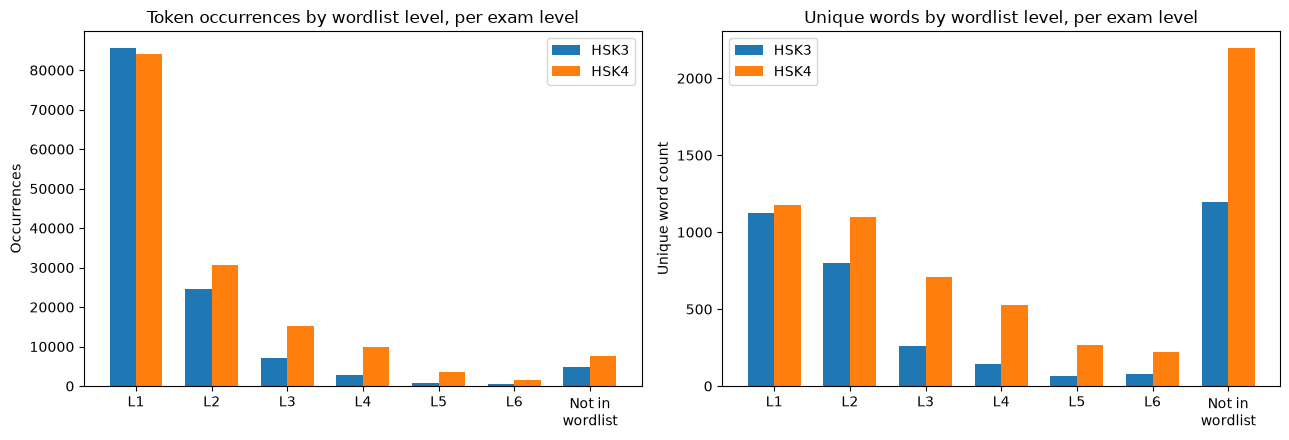

In [13]:
exam_levels = sorted(df_counts["hsk_level"].unique())  # [3, 4]

# ---- 8a: vocabulary coverage per exam level ----
cov_rows = []
for lv in exam_levels:
    sub = df_counts[df_counts["hsk_level"] == lv]
    sub_unique = sub.drop_duplicates("word")
    cov_rows.append({
        "hsk_level": lv,
        "unique_matched":   sub_unique["effective_level"].notna().sum(),
        "unique_unmatched": sub_unique["effective_level"].isna().sum(),
        "occ_matched":      sub.loc[sub["effective_level"].notna(), "count"].sum(),
        "occ_unmatched":    sub.loc[sub["effective_level"].isna(), "count"].sum(),
    })
cov_by_exam_level = pd.DataFrame(cov_rows).set_index("hsk_level")
print("Coverage by exam HSK level (direct + decomposed vs still-unmatched):")
display(cov_by_exam_level)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x = np.arange(len(exam_levels))
width = 0.35

axes[0].bar(x - width/2, cov_by_exam_level["unique_matched"],   width, label="In wordlist",     color="#4C72B0")
axes[0].bar(x + width/2, cov_by_exam_level["unique_unmatched"], width, label="Not in wordlist", color="#DD8452")
axes[0].set_xticks(x); axes[0].set_xticklabels([f"HSK{lv}" for lv in exam_levels])
axes[0].set_title("Unique words by exam level"); axes[0].set_ylabel("Unique word count")
axes[0].legend()

axes[1].bar(x - width/2, cov_by_exam_level["occ_matched"],   width, label="In wordlist",     color="#4C72B0")
axes[1].bar(x + width/2, cov_by_exam_level["occ_unmatched"], width, label="Not in wordlist", color="#DD8452")
axes[1].set_xticks(x); axes[1].set_xticklabels([f"HSK{lv}" for lv in exam_levels])
axes[1].set_title("Token occurrences by exam level"); axes[1].set_ylabel("Total occurrences")
axes[1].legend()

plt.tight_layout()
plt.show()

# ---- 8b: word frequency (by effective wordlist level 1-6) split by exam level ----
# Uses a local column, not stored back on df_counts, so the saved parquet
# schema in section 5 stays exactly as documented.
wordlist_order = [f"L{i}" for i in range(1, 7)] + ["Not in\nwordlist"]
wordlist_level_label = df_counts["effective_level"].apply(
    lambda x: f"L{int(x)}" if pd.notna(x) else "Not in\nwordlist"
)
df_counts_labeled = df_counts.assign(wordlist_level_label=wordlist_level_label)

occ_by_both = (
    df_counts_labeled.groupby(["wordlist_level_label", "hsk_level"])["count"].sum()
    .unstack("hsk_level").reindex(wordlist_order).fillna(0)
)
uniq_by_both = (
    df_counts_labeled.drop_duplicates(["word", "hsk_level"])
    .groupby(["wordlist_level_label", "hsk_level"])["word"].count()
    .unstack("hsk_level").reindex(wordlist_order).fillna(0)
)

print("\nToken occurrences by effective wordlist level, split by exam level:")
display(occ_by_both)
print("\nUnique words by effective wordlist level, split by exam level:")
display(uniq_by_both)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
xw = np.arange(len(wordlist_order))

for i, lv in enumerate(exam_levels):
    offset = (i - (len(exam_levels) - 1) / 2) * width
    axes[0].bar(xw + offset, occ_by_both[lv], width, label=f"HSK{lv}")
    axes[1].bar(xw + offset, uniq_by_both[lv], width, label=f"HSK{lv}")

axes[0].set_xticks(xw); axes[0].set_xticklabels(wordlist_order)
axes[0].set_title("Token occurrences by wordlist level, per exam level")
axes[0].set_ylabel("Occurrences"); axes[0].legend()

axes[1].set_xticks(xw); axes[1].set_xticklabels(wordlist_order)
axes[1].set_title("Unique words by wordlist level, per exam level")
axes[1].set_ylabel("Unique word count"); axes[1].legend()

plt.tight_layout()
plt.show()

## 9 — Export still-unmatched words for manual review

Not every unmatched word belongs in the wordlist, so this doesn't try to
auto-classify them — it exports enough context (frequency, exam spread,
length, whether the individual characters are each independently known) for
a human to triage quickly:

- **2-char, all component chars known** — usually the strongest "probably a
  real missing word" signal (e.g. `问好`, `你好` are both like this: 你/您/问/好
  are all in the wordlist individually, they're just missing as 2-char
  entries) — check these first.
- **≥3 chars** — often instructional/exam-specific phrases ("这段话" = "this
  passage", from listening instructions) or real compound nouns (会议室,
  火车站) — lower priority, mixed bag.
- **Proper nouns** (小王, 小李, 小米...) — should stay excluded, not a gap.

Investigated but **not applied**: a generic "any known char + 好" suffix rule
(好 as a resultative-complement suffix: 做好/学好/说好/你好 are real, but the
same rule also produces nonsense like `题好`/`无好`/`早好`/`门好` — the risk of
polluting `effective_level` with wrong matches outweighs the ~400 occurrences
it would additionally cover). Left as `unmatched` and included in this export
instead, so a human can pick out the real ones (你好, 您好, 问好, 做好, ...)
for a source-list fix.

**`likely_noise` flag:** words that appear only **once**, in only **one** exam
file, are far more likely to be a Whisper mis-hearing or PDF OCR/segmentation
artifact than a real word someone would deliberately test — real vocabulary
tends to recur across multiple exam papers. This is a heuristic (not a
guarantee) — it flags for review, it doesn't delete anything. 50.8% of
unmatched words hit this threshold, which matches what section 3b's earlier
naive-decomposition experiment showed: most true one-off garbage
(`时哭`, `学五`, `天短`) was low-frequency, isolated-to-one-file noise.

### 9a — Cross-check against CC-CEDICT (external dictionary)

`in_jieba_dict` turned out weaker than expected: jieba's built-in dict is a
statistical corpus dictionary (349k entries including common collocations
that aren't necessarily real fixed words), not a curated lexicon, so it
over-recognizes things. Tested re-segmenting the "genuine noise" bucket with
`jieba.lcut(word, HMM=False)` too — 83.5% split into "all pieces individually
known," but that includes obvious nonsense (`风小`, `讲边`, `后成`,
`难常回`) just as often as real compounds, because almost any two common
Chinese characters can combine into "known pieces" without being a real word.
Neither signal reliably separates noise from real vocabulary.

**CC-CEDICT** (community-maintained Chinese-English dictionary, ~121k curated
headwords, published by MDBG, CC BY-SA 4.0 license) is a much stricter
signal — it only contains words someone deliberately entered as a real
lexeme, not statistically common bigrams. Already loaded in section 0d (both
as `cedict_words` and into jieba itself) — reused here directly, no need to
download/parse it again.

In [14]:
def all_chars_known(word: str) -> bool:
    return all(word_to_level.get(c) is not None for c in word)

unmatched_export = (
    df_counts[df_counts["match_type"] == "unmatched"]
    .groupby("word")
    .agg(
        total_count=("count", "sum"),
        exam_count=("exam_id", "nunique"),
        hsk_levels_seen=("hsk_level", lambda s: ",".join(sorted(set(str(x) for x in s)))),
        source_types_seen=("source_type", lambda s: ",".join(sorted(set(s)))),
    )
    .reset_index()
)
unmatched_export["char_length"] = unmatched_export["word"].str.len()
unmatched_export["all_chars_known"] = unmatched_export["word"].apply(all_chars_known)

# Heuristic 1: seen once, in only one exam -> more likely a Whisper mis-hearing
# or OCR/segmentation artifact than real vocabulary someone deliberately
# tested. Flags for review, does not drop anything.
unmatched_export["likely_noise"] = (
    (unmatched_export["total_count"] <= 2) & (unmatched_export["exam_count"] == 1)
)

# Heuristic 2: does jieba's OWN dictionary recognize this word? (weaker than
# expected -- see section 9a, jieba's dict over-recognizes statistical
# collocations that aren't real fixed words)
unmatched_export["in_jieba_dict"] = unmatched_export["word"].apply(lambda w: jieba.dt.FREQ.get(w, 0) > 0)

# Heuristic 3 (strongest): is this word a headword in CC-CEDICT, a curated
# ~121k-entry Chinese-English dictionary? See section 9a for the comparison
# against in_jieba_dict / naive resplitting.
unmatched_export["in_cedict"] = unmatched_export["word"].isin(cedict_words)

unmatched_export = unmatched_export.sort_values("total_count", ascending=False).reset_index(drop=True)

export_path = PROCESSED_DIR / "unmatched_words_review.csv"
unmatched_export.to_csv(export_path, index=False, encoding="utf-8-sig")
print(f"Saved {len(unmatched_export)} unmatched words -> {export_path}")

print(f"\nFlagged likely_noise:  {unmatched_export['likely_noise'].sum()} / {len(unmatched_export)} "
      f"({unmatched_export['likely_noise'].mean():.1%})")
print(f"in_jieba_dict True:    {unmatched_export['in_jieba_dict'].sum()} / {len(unmatched_export)} "
      f"({unmatched_export['in_jieba_dict'].mean():.1%})")
print(f"in_cedict True:        {unmatched_export['in_cedict'].sum()} / {len(unmatched_export)} "
      f"({unmatched_export['in_cedict'].mean():.1%})")

genuine_noise = unmatched_export[unmatched_export["likely_noise"] & ~unmatched_export["in_jieba_dict"]]
print(f"\n'Genuine noise' bucket (likely_noise & not in_jieba_dict): {len(genuine_noise)} words")
print(f"  Of those, in_cedict True (jieba missed a real word):  {genuine_noise['in_cedict'].sum()} "
      f"({genuine_noise['in_cedict'].mean():.1%})")
print(f"  Of those, in_cedict False (confirmed likely noise):   {(~genuine_noise['in_cedict']).sum()} "
      f"({(~genuine_noise['in_cedict']).mean():.1%})")

print("\nStrongest fix candidates: 2-char words, all chars known, "
      "recognized by BOTH jieba's dict AND CC-CEDICT, not flagged as noise "
      "(highest-confidence 'this is a real word missing from our HSK wordlist'):")
display(
    unmatched_export[
        (unmatched_export["char_length"] == 2)
        & unmatched_export["all_chars_known"]
        & unmatched_export["in_jieba_dict"]
        & unmatched_export["in_cedict"]
        & ~unmatched_export["likely_noise"]
    ].head(25)
)

print("\nStrongest genuine-noise candidates: likely_noise=True AND neither "
      "jieba's dict NOR CC-CEDICT recognizes the word (triple signal, "
      "highest-confidence 'this is ASR/OCR garbage, not a word'):")
display(
    unmatched_export[
        unmatched_export["likely_noise"]
        & ~unmatched_export["in_jieba_dict"]
        & ~unmatched_export["in_cedict"]
    ].sample(15, random_state=42)
)

print("\nWords CC-CEDICT rescued from the 'genuine noise' bucket "
      "(jieba missed these, but they're real dictionary words):")
display(genuine_noise[genuine_noise["in_cedict"]].sort_values("total_count", ascending=False))

Saved 2943 unmatched words -> C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\processed\unmatched_words_review.csv

Flagged likely_noise:  1632 / 2943 (55.5%)
in_jieba_dict True:    1973 / 2943 (67.0%)
in_cedict True:        1034 / 2943 (35.1%)

'Genuine noise' bucket (likely_noise & not in_jieba_dict): 653 words
  Of those, in_cedict True (jieba missed a real word):  16 (2.5%)
  Of those, in_cedict False (confirmed likely noise):   637 (97.5%)

Strongest fix candidates: 2-char words, all chars known, recognized by BOTH jieba's dict AND CC-CEDICT, not flagged as noise (highest-confidence 'this is a real word missing from our HSK wordlist'):


,word,total_count,exam_count,hsk_levels_seen,source_types_seen,char_length,all_chars_known,likely_noise,in_jieba_dict,in_cedict
2,填写,137,64,"3,4","listening,reading",2,True,False,True,True
3,总能,119,33,"3,4","listening,reading",2,True,False,True,True
5,有点,111,48,"3,4","listening,reading",2,True,False,True,True
6,书写,99,65,"3,4","listening,reading",2,True,False,True,True
7,选出,96,32,4,reading,2,True,False,True,True
8,下列,95,26,4,"listening,reading",2,True,False,True,True
9,发给,93,33,"3,4","listening,reading",2,True,False,True,True
17,孔子,78,64,"3,4",reading,2,True,False,True,True
20,您好,67,28,"3,4","listening,reading",2,True,False,True,True
28,早点,59,34,"3,4",listening,2,True,False,True,True



Strongest genuine-noise candidates: likely_noise=True AND neither jieba's dict NOR CC-CEDICT recognizes the word (triple signal, highest-confidence 'this is ASR/OCR garbage, not a word'):


,word,total_count,exam_count,hsk_levels_seen,source_types_seen,char_length,all_chars_known,likely_noise,in_jieba_dict,in_cedict
1944,要招,1,1,4,reading,2,True,True,False,False
1850,办护,1,1,4,reading,2,True,True,False,False
1195,身在,2,1,4,reading,2,False,True,False,False
2558,汤二,1,1,4,listening,2,True,True,False,False
2543,小冬来,1,1,3,listening,3,True,True,False,False
1189,美有,2,1,4,"listening,reading",2,True,True,False,False
2911,很简,1,1,3,reading,2,False,True,False,False
1558,刘阳,2,1,3,reading,2,False,True,False,False
1900,记着,1,1,4,listening,2,True,True,False,False
2596,是题,1,1,3,reading,2,True,True,False,False



Words CC-CEDICT rescued from the 'genuine noise' bucket (jieba missed these, but they're real dictionary words):


,word,total_count,exam_count,hsk_levels_seen,source_types_seen,char_length,all_chars_known,likely_noise,in_jieba_dict,in_cedict
1126,马云,2,1,3,"listening,reading",2,True,True,False,True
1412,周公,2,1,4,reading,2,True,True,False,True
1420,天后,2,1,4,reading,2,True,True,False,True
1499,人中,2,1,4,"listening,reading",2,True,True,False,True
1631,手洗,2,1,4,"listening,reading",2,True,True,False,True
1832,怎能,1,1,4,reading,2,False,True,False,True
1871,总有,1,1,4,reading,2,True,True,False,True
1920,急着,1,1,3,listening,2,True,True,False,True
2069,鸡年,1,1,3,reading,2,True,True,False,True
2371,女大,1,1,3,reading,2,True,True,False,True


### 9b -- Export just the CC-CEDICT-confirmed subset

Same as section 9, but filtered to `in_cedict == True` only -- the
highest-confidence "this is a real Chinese word, just missing from our HSK
snapshot" candidates, sorted by frequency. Separate file so it can be
handed off for the source-wordlist fix without wading through the full
4,000+ row review file.

In [15]:
cedict_confirmed = unmatched_export[unmatched_export["in_cedict"]].sort_values("total_count", ascending=False)
cedict_export_path = PROCESSED_DIR / "unmatched_words_in_cedict.csv"
cedict_confirmed.to_csv(cedict_export_path, index=False, encoding="utf-8-sig")
print(f"Saved {len(cedict_confirmed)} CC-CEDICT-confirmed words -> {cedict_export_path}")
display(cedict_confirmed.head(25))

Saved 1034 CC-CEDICT-confirmed words -> C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\processed\unmatched_words_in_cedict.csv


,word,total_count,exam_count,hsk_levels_seen,source_types_seen,char_length,all_chars_known,likely_noise,in_jieba_dict,in_cedict
1,会议室,200,38,"3,4","listening,reading",3,False,False,True,True
2,填写,137,64,"3,4","listening,reading",2,True,False,True,True
3,总能,119,33,"3,4","listening,reading",2,True,False,True,True
5,有点,111,48,"3,4","listening,reading",2,True,False,True,True
6,书写,99,65,"3,4","listening,reading",2,True,False,True,True
7,选出,96,32,4,reading,2,True,False,True,True
8,下列,95,26,4,"listening,reading",2,True,False,True,True
9,发给,93,33,"3,4","listening,reading",2,True,False,True,True
10,上下班,91,42,"3,4","listening,reading",3,True,False,True,True
11,儿,89,48,"3,4","listening,reading",1,False,False,True,True


## 10 — Confusion matrices for the noise-detection heuristics

Section 9's `likely_noise` and `in_jieba_dict` are both heuristics for "is
this unmatched word real Chinese vocabulary or ASR/OCR noise?" — using
`in_cedict` as a ground-truth proxy (a word IS real if a curated 121k-entry
dictionary has it; note this proxy itself has false negatives, since
CC-CEDICT isn't 100% exhaustive either, so treat these as approximate, not
exact).

- **Predicted "real"** for `likely_noise`: `NOT likely_noise`
- **Predicted "real"** for `in_jieba_dict`: `in_jieba_dict` itself
- **Ground truth "real"**: `in_cedict`

Plotted as standard 2×2 confusion matrices (rows = actual, columns =
predicted), plus precision/recall/F1 for each heuristic against the proxy.

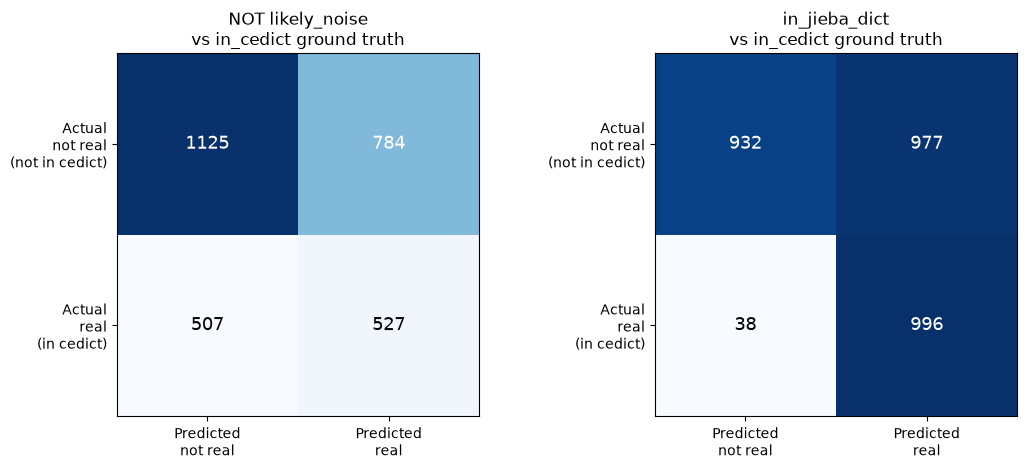

Metrics vs in_cedict ground-truth proxy:


,TP,FP,FN,TN,precision,recall,f1,accuracy
heuristic,,,,,,,,
NOT likely_noise,527,784,507,1125,0.402,0.510,0.449,0.561
in_jieba_dict,996,977,38,932,0.505,0.963,0.662,0.655


In [16]:
def confusion_counts(predicted_real: pd.Series, actual_real: pd.Series):
    tp = int((predicted_real & actual_real).sum())
    fp = int((predicted_real & ~actual_real).sum())
    fn = int((~predicted_real & actual_real).sum())
    tn = int((~predicted_real & ~actual_real).sum())
    return tp, fp, fn, tn

def metrics_from_counts(tp, fp, fn, tn):
    precision = tp / (tp + fp) if (tp + fp) else float("nan")
    recall    = tp / (tp + fn) if (tp + fn) else float("nan")
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else float("nan")
    accuracy  = (tp + tn) / (tp + fp + fn + tn)
    return precision, recall, f1, accuracy

actual_real = unmatched_export["in_cedict"]
heuristics = {
    "NOT likely_noise": ~unmatched_export["likely_noise"],
    "in_jieba_dict":    unmatched_export["in_jieba_dict"],
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
metrics_rows = []

for ax, (name, predicted_real) in zip(axes, heuristics.items()):
    tp, fp, fn, tn = confusion_counts(predicted_real, actual_real)
    matrix = np.array([[tn, fp], [fn, tp]])  # rows: actual [not real, real], cols: predicted [not real, real]

    im = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted\nnot real", "Predicted\nreal"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual\nnot real\n(not in cedict)", "Actual\nreal\n(in cedict)"])
    ax.set_title(f"{name}\nvs in_cedict ground truth")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center",
                     color="white" if matrix[i, j] > matrix.max() / 2 else "black", fontsize=13)

    precision, recall, f1, accuracy = metrics_from_counts(tp, fp, fn, tn)
    metrics_rows.append({
        "heuristic": name, "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "precision": precision, "recall": recall, "f1": f1, "accuracy": accuracy,
    })

plt.tight_layout()
plt.show()

print("Metrics vs in_cedict ground-truth proxy:")
display(pd.DataFrame(metrics_rows).set_index("heuristic").round(3))

## 11 — Other useful plots: pipeline funnel & the CC-CEDICT-in-jieba experiment

Two more visuals worth keeping for the portfolio writeup:

1. **Coverage funnel** — how much of the corpus gets matched at each pipeline
   stage (direct wordlist match → + decomposition fallback), by occurrence
   count.
2. **CC-CEDICT-in-jieba experiment (reverted)** — the before/after comparison
   from section 0d, plotted instead of just tabulated, since it's a concrete
   "we tried X, measured it, it made things worse" result worth showing.

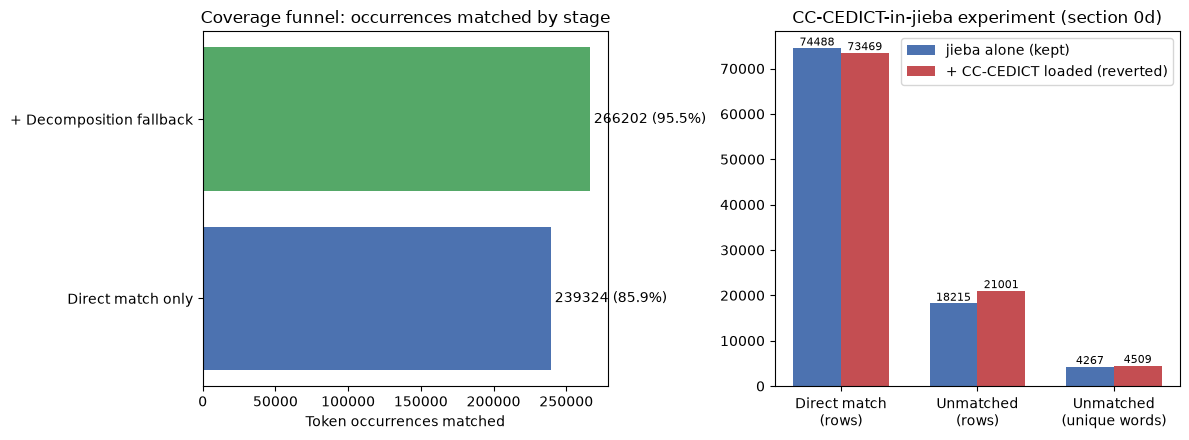

In [17]:
# ---- 11a: coverage funnel (occurrence-based) ----
total_occ = df_counts["count"].sum()
direct_occ = df_counts.loc[df_counts["match_type"] == "direct", "count"].sum()
decomposed_occ_ = df_counts.loc[df_counts["match_type"] == "decomposed", "count"].sum()

funnel_stages = ["Direct match only", "+ Decomposition fallback"]
funnel_values = [direct_occ, direct_occ + decomposed_occ_]
funnel_pct = [v / total_occ for v in funnel_values]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].barh(funnel_stages, funnel_values, color=["#4C72B0", "#55A868"])
axes[0].set_xlim(0, total_occ)
axes[0].set_title("Coverage funnel: occurrences matched by stage")
axes[0].set_xlabel("Token occurrences matched")
for i, (v, p) in enumerate(zip(funnel_values, funnel_pct)):
    axes[0].text(v, i, f" {v} ({p:.1%})", va="center")

# ---- 11b: CC-CEDICT-in-jieba experiment, before vs after (reverted) ----
exp_labels = ["Direct match\n(rows)", "Unmatched\n(rows)", "Unmatched\n(unique words)"]
before_vals = [74488, 18215, 4267]
after_vals  = [73469, 21001, 4509]

x = np.arange(len(exp_labels))
width = 0.35
axes[1].bar(x - width/2, before_vals, width, label="jieba alone (kept)", color="#4C72B0")
axes[1].bar(x + width/2, after_vals,  width, label="+ CC-CEDICT loaded (reverted)", color="#C44E52")
axes[1].set_xticks(x); axes[1].set_xticklabels(exp_labels)
axes[1].set_title("CC-CEDICT-in-jieba experiment (section 0d)")
axes[1].legend()
for i, (b, a) in enumerate(zip(before_vals, after_vals)):
    axes[1].text(i - width/2, b, str(b), ha="center", va="bottom", fontsize=8)
    axes[1].text(i + width/2, a, str(a), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 12 -- Save

In [18]:
save_parquet(df_counts, PROCESSED_DIR / "word_counts.parquet")
df_counts.to_csv(PROCESSED_DIR / "word_counts.csv", index=False, encoding="utf-8-sig")
print(f"Saved {len(df_counts)} rows -> {PROCESSED_DIR / 'word_counts.parquet/.csv'}")

Saved 102315 rows -> C:\Users\callm\OneDrive\Desktop\HSK-Vocabulary-Frequency\data\processed\word_counts.parquet\.csv
